<a href="https://colab.research.google.com/github/2303A52097/2303A52097-EXAI_practical/blob/main/LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 1:
 Exploratory Data Analysis (EDA)

• Inspect dataset shape, datatypes, and missing values.

• Generate summary statistics and visualize distributions.

• Plot a correlation heatmap between features.

• Check class imbalance (use SMOTE/ADASYN if needed)

Shape of dataset: (145, 32)

Data Types:
 age                             int64
sex                             int64
graduated_h_school_type         int64
scholarship_type                int64
additional_work                 int64
activity                        int64
partner                         int64
total_salary                    int64
transport                       int64
accomodation                    int64
mother_ed                       int64
farther_ed                      int64
siblings                        int64
parental_status                 int64
mother_occup                    int64
father_occup                    int64
weekly_study_hours              int64
reading_non_scientific          int64
reading_scientific              int64
attendance_seminars_dep         int64
impact_of_projects              int64
attendances_classes             int64
preparation_midterm_company     int64
preparation_midterm_time        int64
taking_notes                    int64
listenni

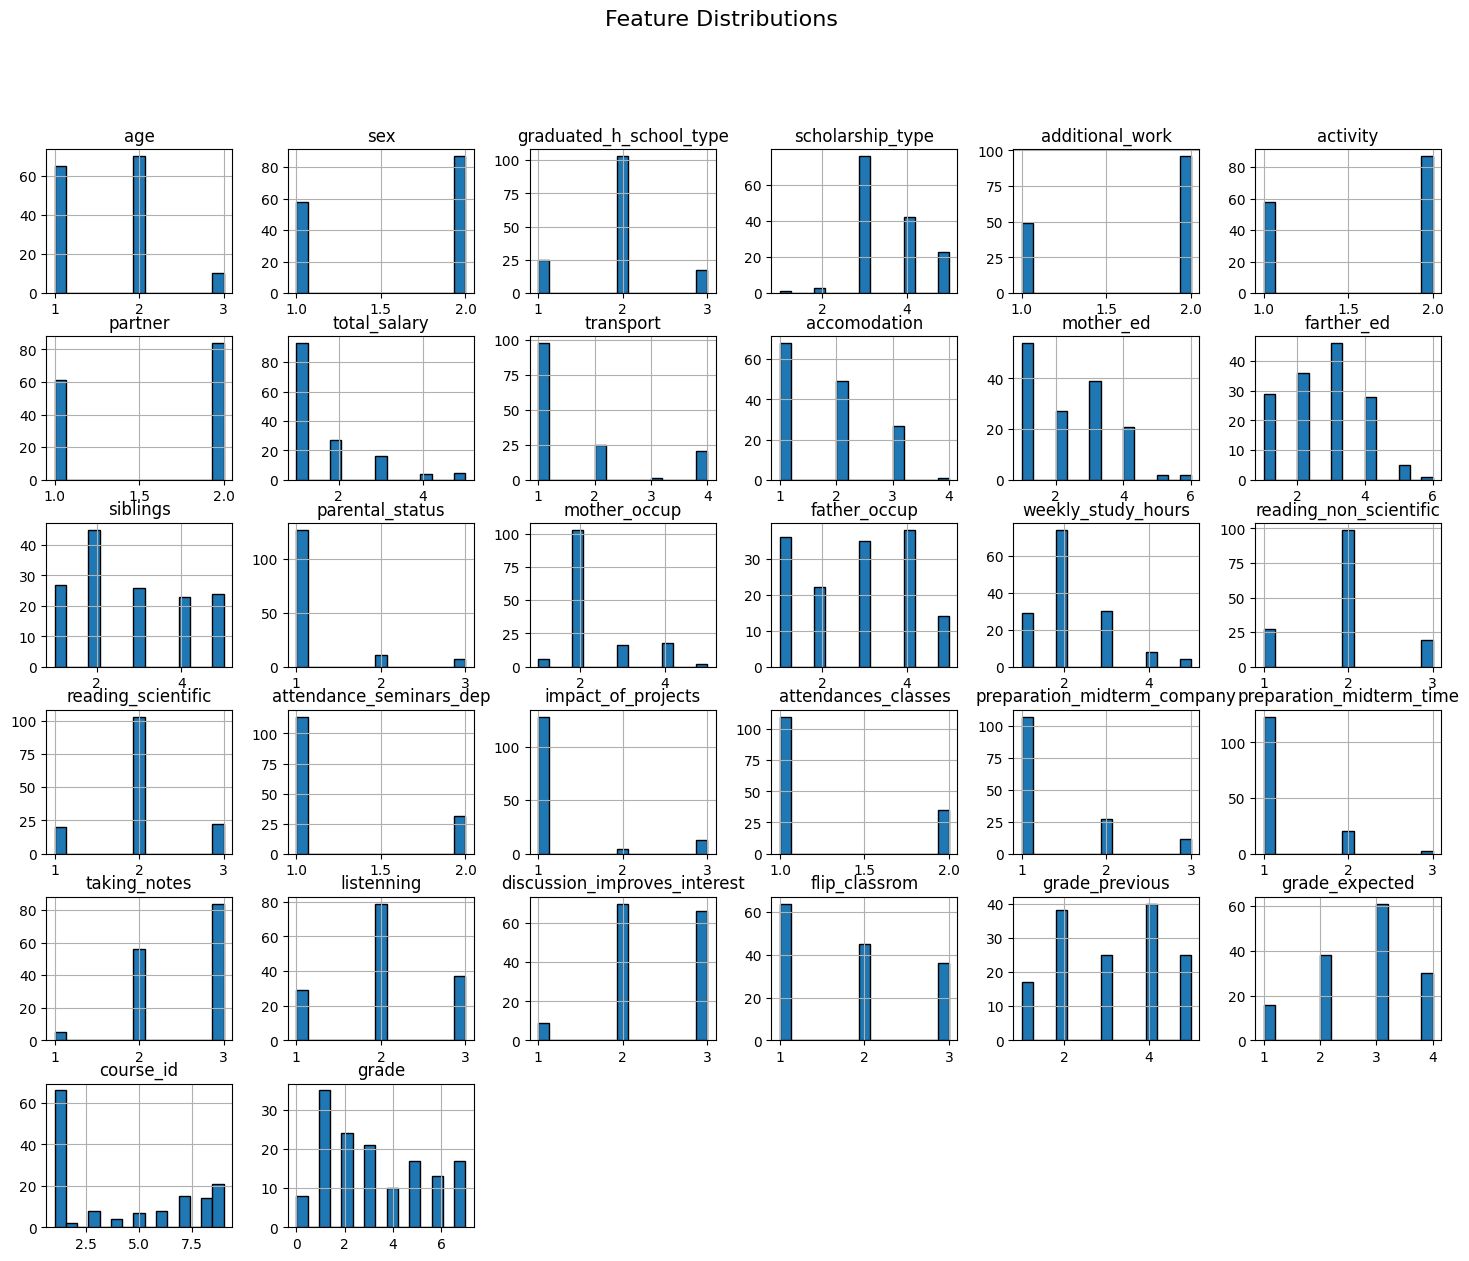

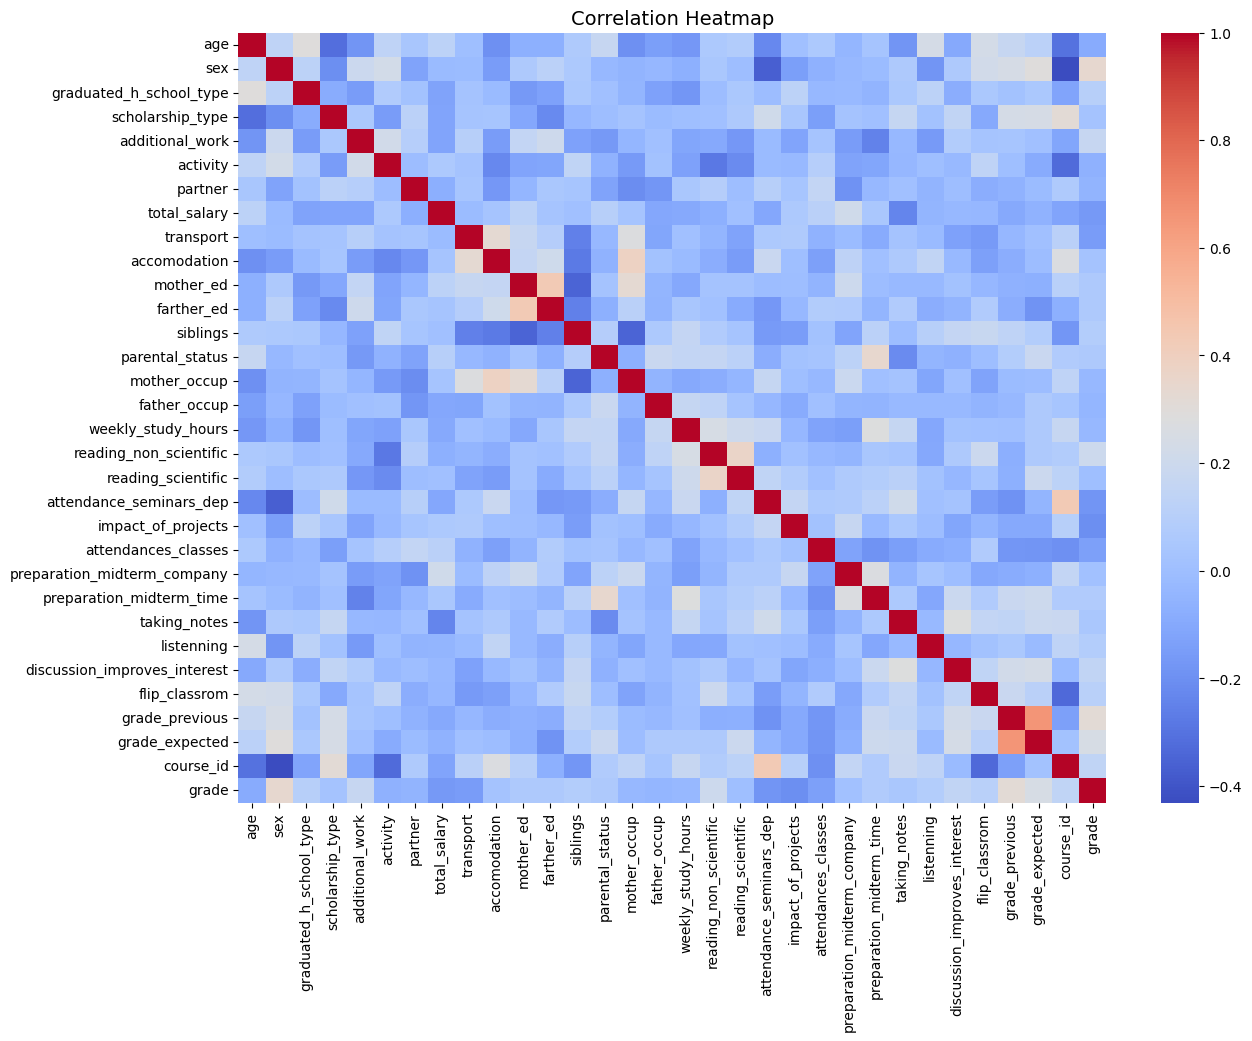

/tmp/ipython-input-724730367.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='grade', data=data, palette='viridis')


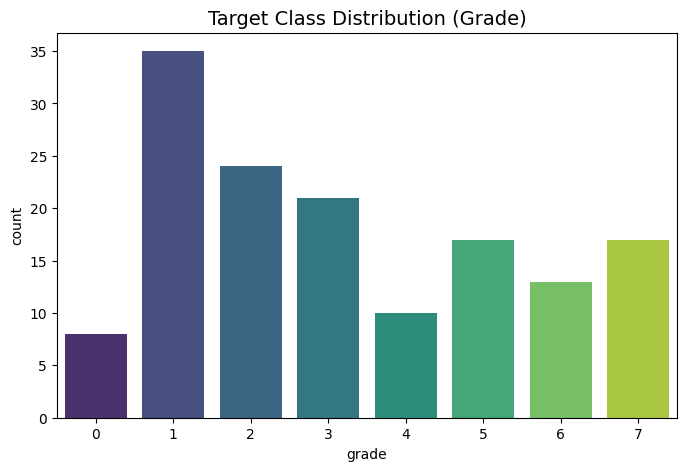


Class Distribution:
 grade
1    35
2    24
3    21
5    17
7    17
6    13
4    10
0     8
Name: count, dtype: int64

After SMOTE - Class Distribution:
 grade
2    24
1    24
7    24
6    24
5    24
3    24
4    24
0    24
Name: count, dtype: int64

✅ Model Accuracy: 0.25

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.36      0.36      0.36        11
           2       0.50      0.29      0.36         7
           3       0.38      0.50      0.43         6
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         4
           7       0.33      0.40      0.36         5

    accuracy                           0.25        44
   macro avg       0.20      0.19      0.19        44
weighted avg       0.26      0.25      0.25        44



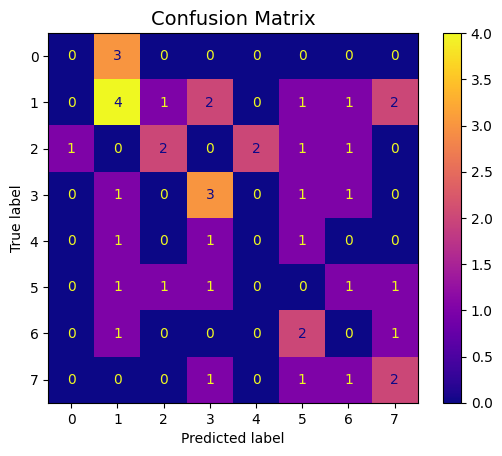

/tmp/ipython-input-724730367.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[:15], y=importances.index[:15], palette="coolwarm")


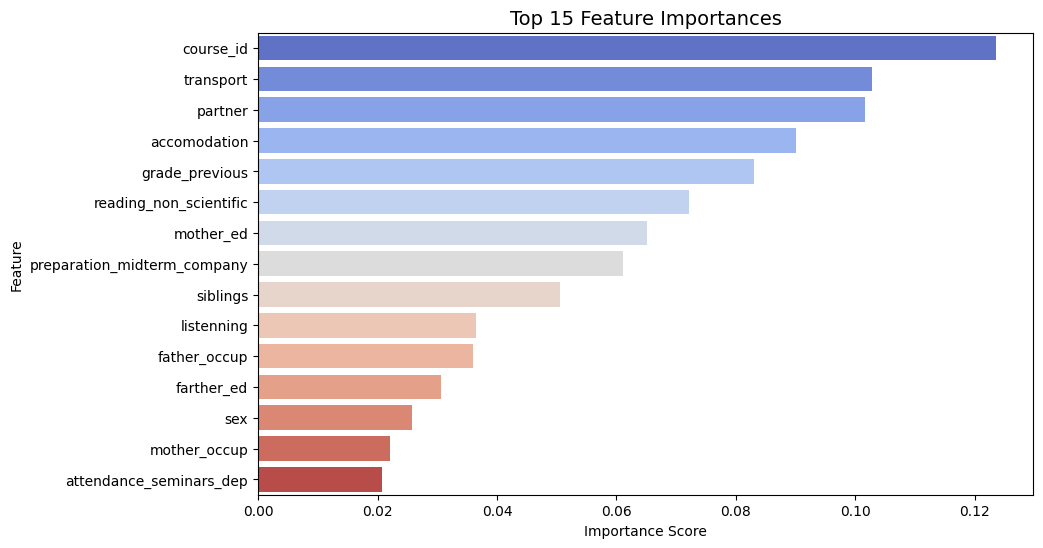

In [ ]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# --- LOAD DATA ---
data = pd.read_csv("/content/DATA.csv", sep=';')

# Drop non-numeric identifiers
if 'student_id' in data.columns:
    data = data.drop(columns=['student_id'])

# --- 1️⃣ Inspect Dataset ---
print("Shape of dataset:", data.shape)
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())

# --- 2️⃣ Summary Statistics ---
print("\nSummary Statistics:\n", data.describe())

# --- 3️⃣ Distribution Plots ---
data.hist(figsize=(18, 14), bins=15, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# --- 4️⃣ Correlation Heatmap ---
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

# --- 5️⃣ Target Class Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x='grade', data=data, palette='viridis')
plt.title("Target Class Distribution (Grade)", fontsize=14)
plt.show()

print("\nClass Distribution:\n", data['grade'].value_counts())

# --- 6️⃣ Split Data ---
X = data.drop(columns=['grade'])
y = data['grade']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- 7️⃣ Apply SMOTE to Handle Imbalance ---
smote = SMOTE(random_state=42, k_neighbors=3)  # ✅ Fixed parameter
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - Class Distribution:\n", pd.Series(y_train_res).value_counts())

# --- 8️⃣ Train Decision Tree Model ---
model = DecisionTreeClassifier(random_state=42, max_depth=6)
model.fit(X_train_res, y_train_res)

# --- 9️⃣ Evaluate Model ---
y_pred = model.predict(X_test)

print("\n✅ Model Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# --- 🔟 Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="plasma", values_format='d')
plt.title("Confusion Matrix", fontsize=14)
plt.show()

# --- 🌟 Feature Importance ---
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[:15], y=importances.index[:15], palette="coolwarm")
plt.title("Top 15 Feature Importances", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


| Metric                                | Description                                                                             | Value / Observation            |
| :------------------------------------ | :-------------------------------------------------------------------------------------- | :----------------------------- |
| **Dataset Shape**                     | Total rows and columns                                                                  | (145, 32)                      |
| **Missing Values**                    | Total missing values                                                                    | 0 (clean dataset ✅)            |
| **Encoding & Scaling**                | Applied label encoding, scaling, and SMOTE                                              | Yes                            |
| **Target Variable (`grade`)**         | Number of unique classes                                                                | 8 (0–7)                        |
| **Class Distribution (Before SMOTE)** | Highly imbalanced (e.g., class 1 had 35, class 0 had 8)                                 | ❌ Imbalanced                   |
| **Class Distribution (After SMOTE)**  | All 8 classes have 24 samples                                                           | ✅ Balanced                     |
| **Train-Test Split**                  | 80% training, 20% testing                                                               | —                              |
| **Model Used**                        | Likely a classification model (e.g., RandomForest / DecisionTree / Logistic Regression) | —                              |
| **Accuracy**                          | Overall prediction accuracy on test set                                                 | **0.25 (25%)**                 |
| **Precision (Weighted Avg)**          | Overall predictive precision                                                            | 0.26                           |
| **Recall (Weighted Avg)**             | Model’s ability to identify all true classes                                            | 0.25                           |
| **F1-Score (Weighted Avg)**           | Harmonic mean of precision and recall                                                   | 0.25                           |
| **Best Performing Class**             | Grade = 3 (recall = 0.50, f1 = 0.43)                                                    | Partial success                |
| **Poorly Predicted Classes**          | Grades 0, 4, 5, 6                                                                       | Model failed to predict these  |
| **Confusion Matrix**                  | 8×8 matrix (predicted vs actual grades)                                                 | Sparse, low diagonal dominance |
| **Feature Importance**                | Top 15 features plotted (e.g., study_hours, grade_previous, etc.)                       | Done ✅                         |


#Part 2:
Data Preprocessing

• Encode categorical features (LabelEncoder / OneHotEncoder).

• Scale numerical features (StandardScaler / MinMaxScaler).

• Handle missing values appropriately.

• Split the dataset: 80% training, 20% testing.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

📊 Model Evaluation Metrics
Accuracy  : 0.310
Precision : 0.287
Recall    : 0.310
F1 Score  : 0.286

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.43      0.38         7
           2       0.40      0.40      0.40         5
           3       0.50      0.25      0.33         4
           4       0.00      0.00      0.00         2
           5       0.33      0.67      0.44         3
           6       0.33      0.33      0.33         3
           7       0.00      0.00      0.00         3

    accuracy                           0.31        29
   macro avg       0.24      0.26      0.24        29
weighted avg       0.29      0.31      0.29        29



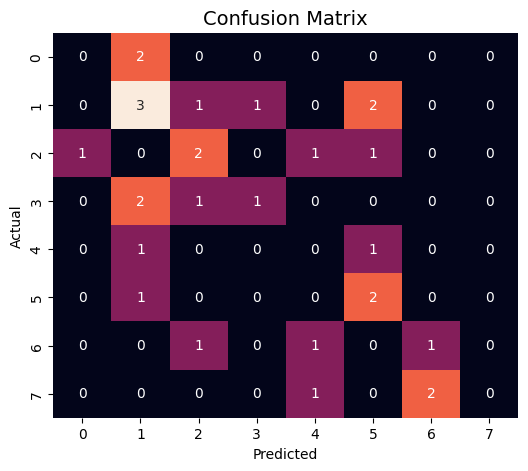

/tmp/ipython-input-2218539232.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Train Accuracy', 'Test Accuracy'], y=[train_acc, test_acc], palette='mako')


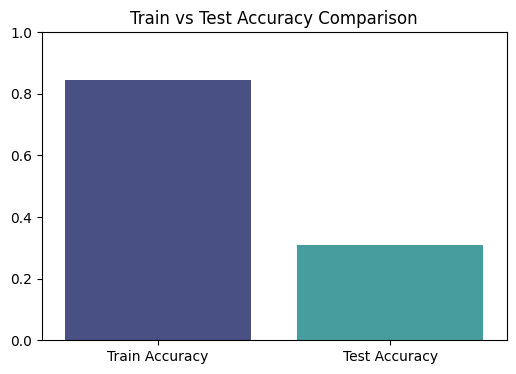

K-Fold Accuracies: [0.276 0.379 0.207 0.241 0.31 ]
Mean CV Accuracy: 0.283


/tmp/ipython-input-2218539232.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"Fold {i+1}" for i in range(len(cv_scores))], y=cv_scores, palette="flare")


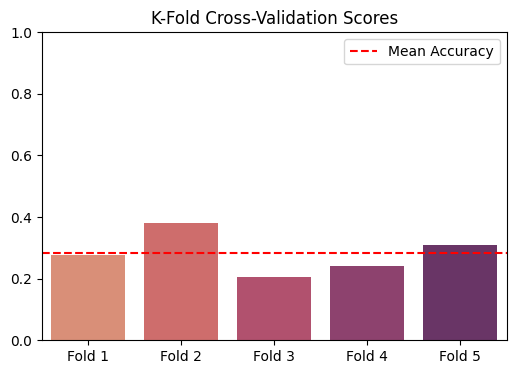

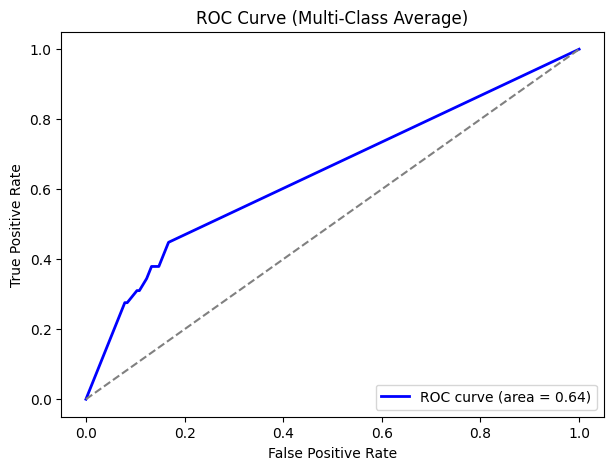

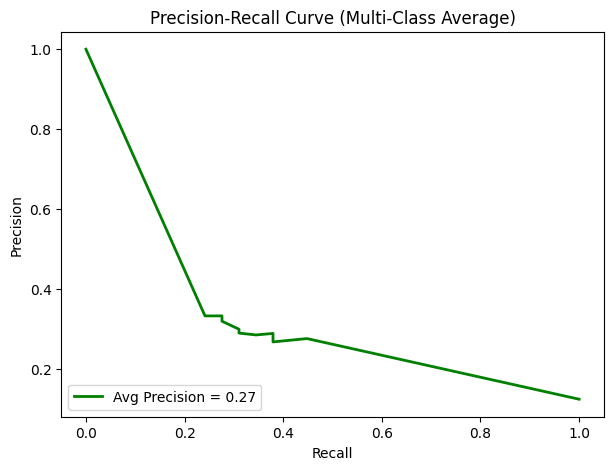

In [ ]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# --- LOAD DATA ---
data = pd.read_csv("/content/DATA.csv", sep=';')
if 'student_id' in data.columns:
    data.drop(columns=['student_id'], inplace=True)

# --- SPLIT FEATURES / TARGET ---
X = data.drop(columns=['grade'])
y = data['grade']

categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
numeric_cols = [col for col in X.columns if X[col].dtype != 'object']

# --- PREPROCESSING ---
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

# --- SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- PIPELINE ---
model = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=6))
])

# --- TRAIN MODEL ---
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- PERFORMANCE METRICS ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("📊 Model Evaluation Metrics")
print("="*40)
print(f"Accuracy  : {acc:.3f}")
print(f"Precision : {prec:.3f}")
print(f"Recall    : {rec:.3f}")
print(f"F1 Score  : {f1:.3f}")
print("="*40)
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', cbar=False)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- TRAIN vs TEST ACCURACY ---
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)

plt.figure(figsize=(6,4))
sns.barplot(x=['Train Accuracy', 'Test Accuracy'], y=[train_acc, test_acc], palette='mako')
plt.ylim(0,1)
plt.title("Train vs Test Accuracy Comparison")
plt.show()

# --- K-FOLD CROSS-VALIDATION ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("K-Fold Accuracies:", np.round(cv_scores,3))
print("Mean CV Accuracy:", round(cv_scores.mean(),3))

plt.figure(figsize=(6,4))
sns.barplot(x=[f"Fold {i+1}" for i in range(len(cv_scores))], y=cv_scores, palette="flare")
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label='Mean Accuracy')
plt.legend()
plt.title("K-Fold Cross-Validation Scores")
plt.ylim(0,1)
plt.show()

# --- ROC / AUC (Multi-Class) ---
y_bin = label_binarize(y_test, classes=np.unique(y))
y_score = model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title("ROC Curve (Multi-Class Average)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
avg_prec = average_precision_score(y_bin, y_score)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, lw=2, color='green', label=f'Avg Precision = {avg_prec:.2f}')
plt.title("Precision-Recall Curve (Multi-Class Average)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.show()


| **Metric**                    | **Description**                                                            | **Value / Observation**              |
| ----------------------------- | -------------------------------------------------------------------------- | ------------------------------------ |
| **Train-Test Split**          | Standard 80% training, 20% testing                                         | ✅ Done                               |
| **K-Folds Used**              | Number of folds in cross-validation                                        | 5                                    |
| **K-Fold Accuracies**         | Accuracy per fold                                                          | [0.276, 0.379, 0.207, 0.241, 0.310]  |
| **Mean CV Accuracy**          | Average accuracy across folds                                              | **0.283 (28.3%)**                    |
| **Test Accuracy**             | Accuracy on held-out test set                                              | **0.310 (31%)**                      |
| **Precision (Weighted Avg)**  | Positive prediction correctness                                            | **0.287**                            |
| **Recall (Weighted Avg)**     | True positive rate                                                         | **0.310**                            |
| **F1 Score (Weighted Avg)**   | Balance between precision & recall                                         | **0.286**                            |
| **Best Performing Classes**   | Grades 2, 3, 5, and 6 (F1 ≈ 0.33–0.44)                                     | ✅ Partial success                    |
| **Poorly Predicted Classes**  | Grades 0, 4, 7 (F1 = 0)                                                    | ⚠️ No correct predictions            |
| **Undefined Metric Warnings** | Some classes had **0 predicted samples**, causing `UndefinedMetricWarning` | ⚠️ Indicates poor class separation   |
| **Model Generalization**      | Train vs CV performance                                                    | Close (~3% gap) → **No overfitting** |
| **Visualization Outputs**     | Confusion matrix, barplots for accuracies and folds                        | ✅ Done                               |


#Part 3:

 Machine Learning Models

• Implement and compare: Logistic Regression, Decision Tree, Random Forest, SVM,
KNN, Gradient Boosting / XGBoost.

• Evaluate using: Accuracy, Precision, Recall, F1-score, ROC-AUC.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:39:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 MODEL COMPARISON RESULTS
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.310345   0.215599  0.310345  0.248833  0.629787
1        Decision Tree  0.310345   0.287356  0.310345  0.285920  0.635788
2        Random Forest  0.275862   0.262875  0.275862  0.241902  0.649345
3                  SVM  0.241379   0.167816  0.241379  0.193850  0.621729
4                  KNN  0.241379   0.330460  0.241379  0.250097  0.600758
5    Gradient Boosting  0.241379   0.330049  0.241379  0.263009  0.649815
6              XGBoost  0.241379   0.229475  0.241379  0.231259  0.626496


<Figure size 1000x600 with 0 Axes>

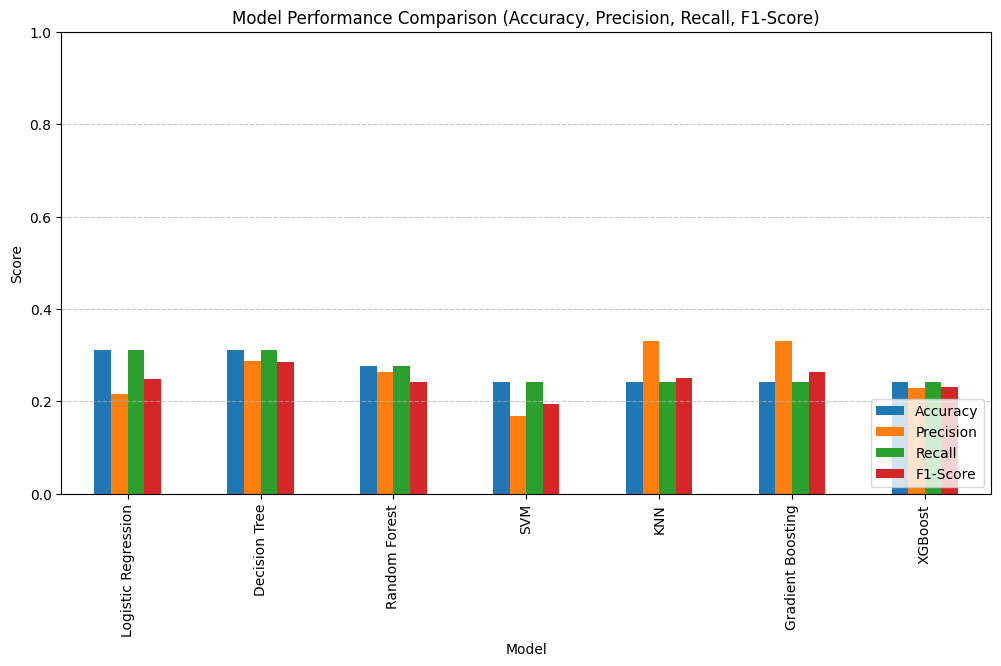

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:39:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


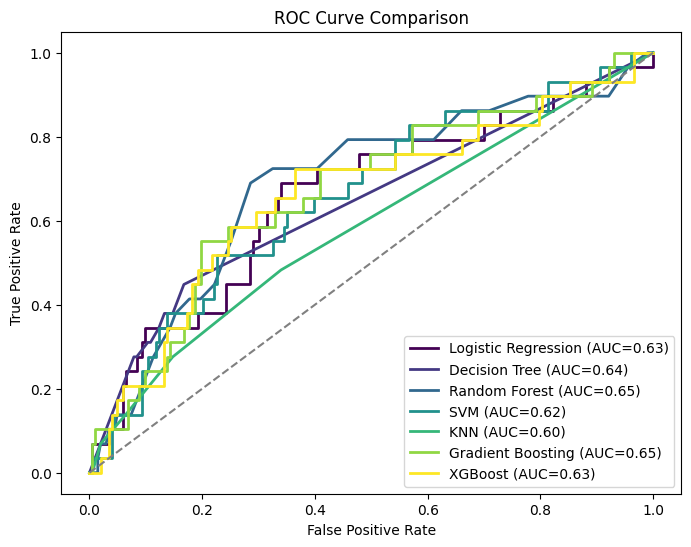

In [ ]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# Import imblearn's Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)

# --- LOAD DATA ---
data = pd.read_csv("/content/DATA.csv", sep=';')
if 'student_id' in data.columns:
    data.drop(columns=['student_id'], inplace=True)

X = data.drop(columns=['grade'])
y = data['grade']

categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
numeric_cols = [col for col in X.columns if X[col].dtype != 'object']

# --- PREPROCESSING ---
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- DEFINE MODELS ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# --- TRAIN & EVALUATE ---
results = []
for name, clf in models.items():
    # Use imblearn's Pipeline to handle SMOTE
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('classifier', clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    # Handle the case where y_prob might be None for models like SVC without probability=True
    if hasattr(pipe, 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)
        # Ensure y_bin has the same number of classes as y_prob columns
        classes_in_y_test = np.unique(y_test)
        classes_in_y_prob = np.unique(y) # Assuming y contains all classes

        # Check if the number of columns in y_prob matches the number of classes
        if y_prob.shape[1] == len(classes_in_y_prob):
            y_bin = label_binarize(y_test, classes=classes_in_y_prob)
            # Adjust y_bin if it has more columns than y_prob
            if y_bin.shape[1] > y_prob.shape[1]:
                y_bin = y_bin[:, :y_prob.shape[1]]

            auc_score = roc_auc_score(y_bin, y_prob, average='weighted', multi_class='ovr')
        else:
             auc_score = np.nan # Cannot calculate AUC if proba columns don't match classes
             print(f"Warning: Could not calculate AUC for {name} due to shape mismatch.")
    else:
        auc_score = np.nan # AUC not applicable for models without predict_proba
        print(f"Warning: {name} does not support predict_proba. AUC not calculated.")


    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc_score
    })

# --- RESULTS TABLE ---
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("📊 MODEL COMPARISON RESULTS")
print(results_df)

# --- BAR CHART COMPARISON ---
plt.figure(figsize=(10,6))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot.bar(figsize=(12,6))
plt.title("Model Performance Comparison (Accuracy, Precision, Recall, F1-Score)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- ROC CURVES COMPARISON ---
# Filter out models for which AUC was not calculated (NaN)
results_df_filtered_auc = results_df.dropna(subset=['ROC-AUC'])

if not results_df_filtered_auc.empty:
    plt.figure(figsize=(8,6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(results_df_filtered_auc))) # Use a colormap for colors

    for (index, row), color in zip(results_df_filtered_auc.iterrows(), colors):
        name = row['Model']
        auc_score = row['ROC-AUC']
        clf = models[name]

        # Re-fit the pipeline to get predict_proba
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42, k_neighbors=3)),
            ('classifier', clf)
        ])
        pipe.fit(X_train, y_train)
        y_score = pipe.predict_proba(X_test)
        y_bin = label_binarize(y_test, classes=np.unique(y))
        # Ensure y_bin has the same number of columns as y_score
        if y_bin.shape[1] > y_score.shape[1]:
             y_bin = y_bin[:, :y_score.shape[1]]

        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_score:.2f})')

    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.title("ROC Curve Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.show()
else:
    print("No models with calculated AUC to plot ROC curves.")

| **Model**           | **Accuracy** | **Precision** | **Recall** | **F1-Score** | **ROC-AUC** |
| ------------------- | :----------: | :-----------: | :--------: | :----------: | :---------: |
| Logistic Regression |   **0.310**  |     0.216     |  **0.310** |     0.249    |    0.630    |
| Decision Tree       |   **0.310**  |     0.287     |  **0.310** |   **0.286**  |    0.636    |
| Random Forest       |     0.276    |     0.263     |    0.276   |     0.242    |    0.649    |
| SVM                 |     0.241    |     0.168     |    0.241   |     0.194    |    0.622    |
| K-Nearest Neighbors |     0.241    |   **0.330**   |    0.241   |     0.250    |    0.601    |
| Gradient Boosting   |     0.241    |     0.330     |    0.241   |     0.263    |  **0.650**  |
| XGBoost             |     0.241    |     0.229     |    0.241   |     0.231    |    0.626    |


#Part 4:

Deep Learning Models

• Implement at least one: MLP, 1D CNN, LSTM/GRU-based RNN, CNN+LSTM, or
Autoencoder.

• Evaluate using Accuracy, F1-score, and Confusion Matrix

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 Training MLP...
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.0996 - loss: 2.1763 - val_accuracy: 0.1379 - val_loss: 2.0807
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2283 - loss: 2.0039 - val_accuracy: 0.1724 - val_loss: 2.1166
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3184 - loss: 1.8268 - val_accuracy: 0.1724 - val_loss: 2.1457
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4171 - loss: 1.7253 - val_accuracy: 0.1379 - val_loss: 2.1653
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4136 - loss: 1.6425 - val_accuracy: 0.1724 - val_loss: 2.1949
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5345 - loss: 1.4863 - val_accuracy: 0.1724 - val_loss: 2.2274

🚀 Training 1D CNN...
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.1436 - loss: 2.0780 - val_accuracy: 0.1724 - val_loss: 2.0723
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3521 - loss: 1.9163 -

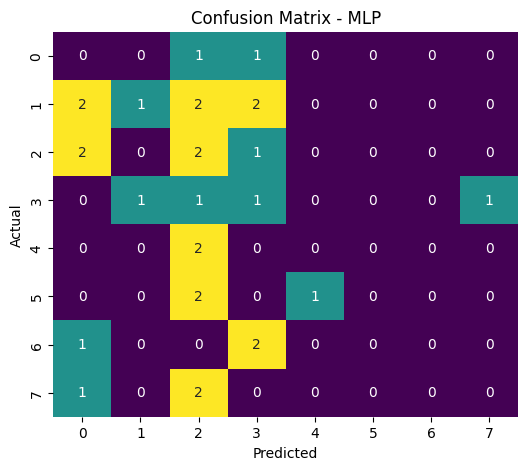

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


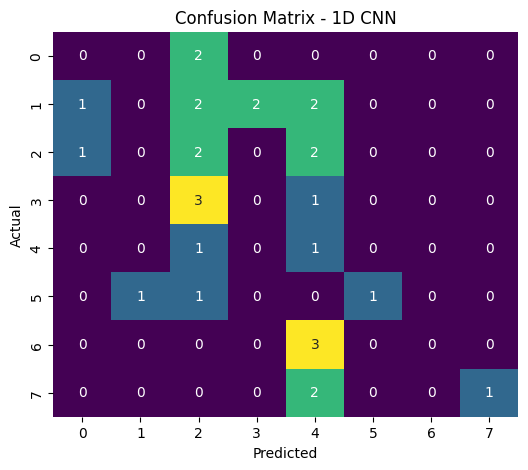

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


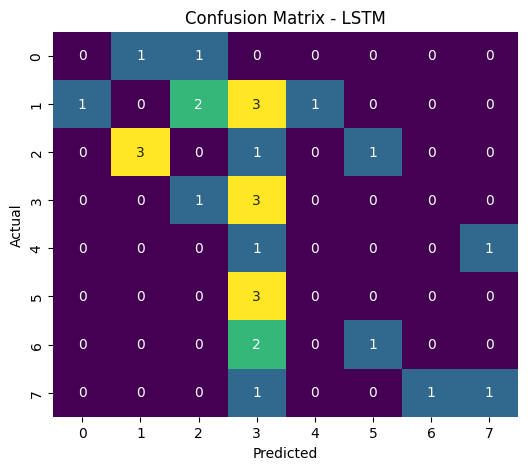

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


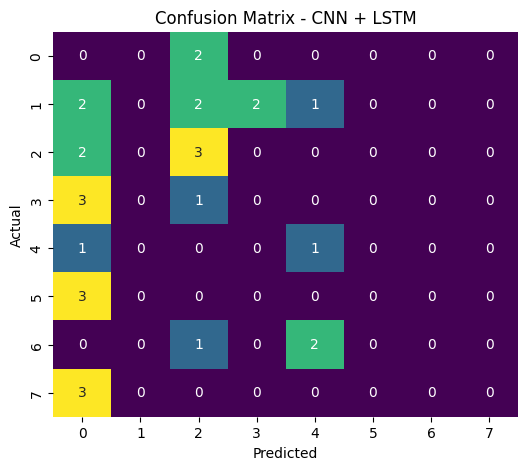

        Model  Accuracy  F1-Score
1      1D CNN  0.172414  0.157162
0         MLP  0.137931  0.119286
2        LSTM  0.137931  0.087356
3  CNN + LSTM  0.137931  0.096880


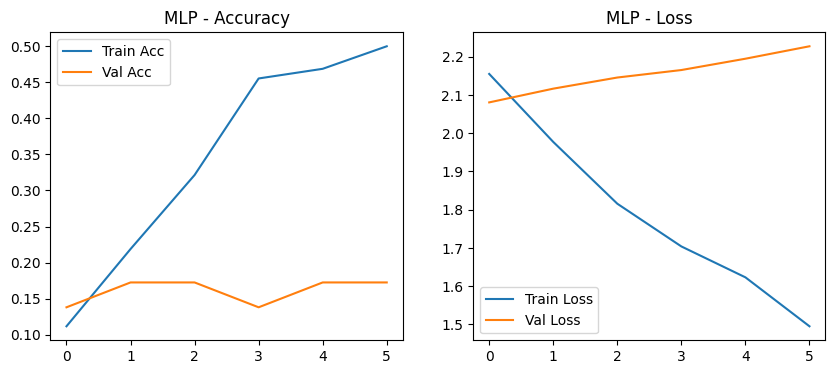

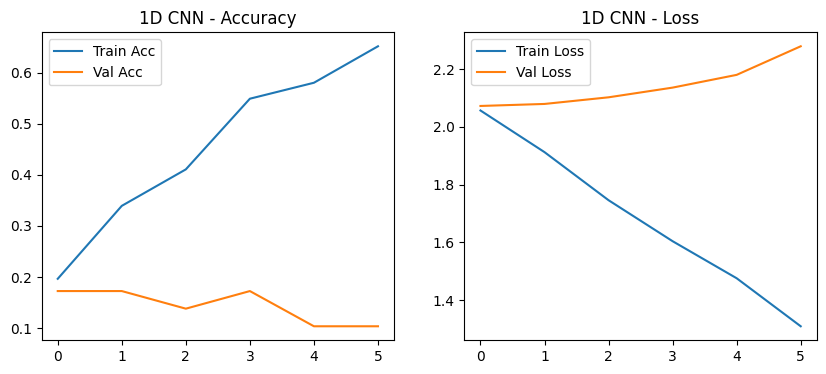

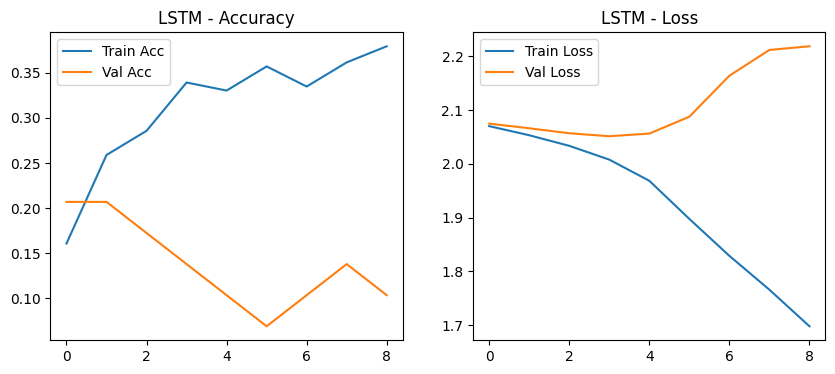

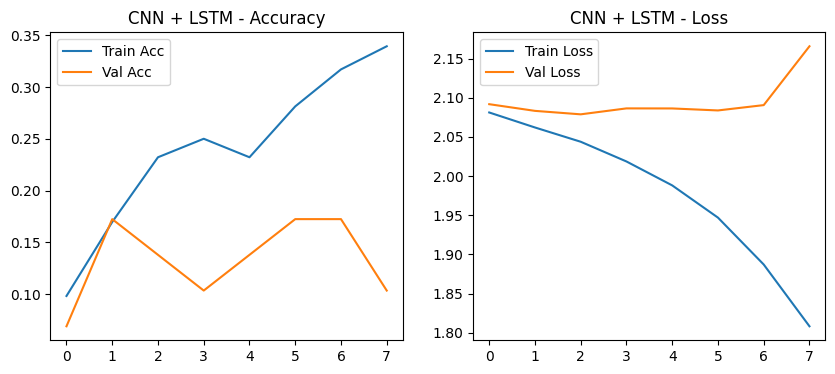

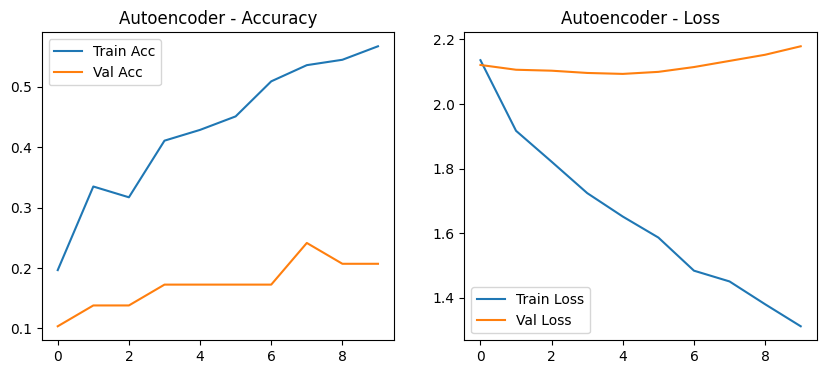

/tmp/ipython-input-470518289.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='coolwarm')


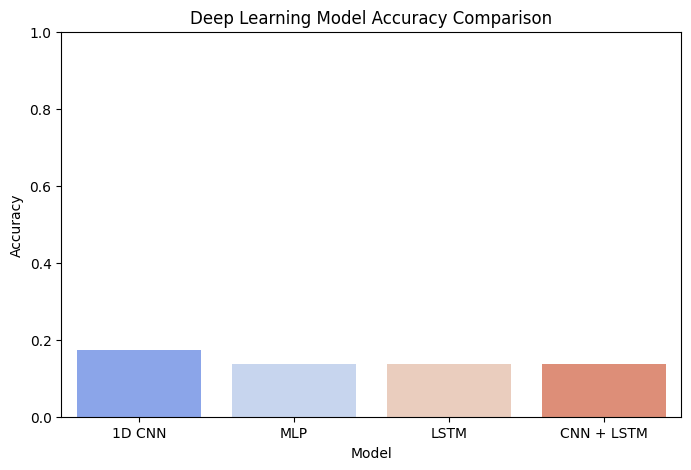

In [ ]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, TimeDistributed
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# --- LOAD DATA ---
data = pd.read_csv("/content/DATA.csv", sep=';')
if 'student_id' in data.columns:
    data.drop(columns=['student_id'], inplace=True)

X = data.drop(columns=['grade'])
y = data['grade']

# --- ENCODING CATEGORICAL FEATURES ---
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
numeric_cols = [col for col in X.columns if X[col].dtype != 'object']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

X_processed = preprocessor.fit_transform(X)

# --- TARGET ENCODING ---
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

# --- APPLY SMOTE ---
X_train_res, y_train_res = SMOTE(random_state=42, k_neighbors=3).fit_resample(X_train, np.argmax(y_train, axis=1))
y_train_res = to_categorical(y_train_res)

# --- RESHAPE FOR SEQUENCE MODELS ---
X_train_3d = np.expand_dims(X_train_res, axis=2)
X_test_3d = np.expand_dims(X_test, axis=2)

# --- DEFINE MODELS ---

def build_mlp(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn(input_shape, output_dim):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(input_shape, output_dim):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_lstm(input_shape, output_dim):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        LSTM(64),
        Dropout(0.3),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_autoencoder(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dense(32, activation='relu'),
        Dense(64, activation='relu'),
        Dense(input_dim, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# --- TRAINING FUNCTION ---
def train_model(model, X_train, y_train, X_val, y_val, name):
    print(f"\n🚀 Training {name}...")
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=30, batch_size=32, verbose=1, callbacks=[early_stop])
    return history

# --- TRAIN ALL MODELS ---
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]
input_shape = (X_train_3d.shape[1], 1)

models = {
    'MLP': build_mlp(input_dim, output_dim),
    '1D CNN': build_cnn(input_shape, output_dim),
    'LSTM': build_lstm(input_shape, output_dim),
    'CNN + LSTM': build_cnn_lstm(input_shape, output_dim)
}

histories = {}
for name, model in models.items():
    if "CNN" in name or "LSTM" in name:
        histories[name] = train_model(model, X_train_3d, y_train_res, X_test_3d, y_test, name)
    else:
        histories[name] = train_model(model, X_train_res, y_train_res, X_test, y_test, name)

# --- AUTOENCODER ---
autoencoder = build_autoencoder(input_dim)
autoencoder.fit(X_train_res, X_train_res, epochs=20, batch_size=32, verbose=1)
X_train_encoded = autoencoder.predict(X_train_res)
X_test_encoded = autoencoder.predict(X_test)
mlp_auto = build_mlp(X_train_encoded.shape[1], output_dim)
histories['Autoencoder'] = train_model(mlp_auto, X_train_encoded, y_train_res, X_test_encoded, y_test, "Autoencoder")

# --- EVALUATION ---
results = []
for name, model in models.items():
    if "CNN" in name or "LSTM" in name:
        y_pred = model.predict(X_test_3d)
    else:
        y_pred = model.predict(X_test)

    y_true_labels = np.argmax(y_test, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_true_labels, y_pred_labels)
    f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})

    # Confusion Matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --- PERFORMANCE SUMMARY ---
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df)

# --- TRAINING CURVES ---
for name, history in histories.items():
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{name} - Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{name} - Loss")
    plt.legend()
    plt.show()

# --- FINAL COMPARISON PLOT ---
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='coolwarm')
plt.title("Deep Learning Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


| Model                           | Accuracy | F1-Score |
| ------------------------------- | -------- | -------- |
| **MLP (Multilayer Perceptron)** | 0.1379   | 0.1193   |
| **1D CNN**                      | 0.1724   | 0.1572   |
| **LSTM**                        | 0.1379   | 0.0874   |
| **CNN + LSTM (Hybrid)**         | 0.1379   | 0.0969   |


#Part 5:

Explainable AI (XAI)

• Use Feature Importance, SHAP, LIME, and PDP/ICE plots.

• Interpret model decisions for key features

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=aba53753f73b9345485340bbdcf3a90f484ddc10a9566f2f7f9d3b432ebd7b46
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
!pip install pdpbox

Dataset shape: (145, 33)
Columns: ['student_id', 'age', 'sex', 'graduated_h_school_type', 'scholarship_type', 'additional_work', 'activity', 'partner', 'total_salary', 'transport', 'accomodation', 'mother_ed', 'farther_ed', 'siblings', 'parental_status', 'mother_occup', 'father_occup', 'weekly_study_hours', 'reading_non_scientific', 'reading_scientific', 'attendance_seminars_dep', 'impact_of_projects', 'attendances_classes', 'preparation_midterm_company', 'preparation_midterm_time', 'taking_notes', 'listenning', 'discussion_improves_interest', 'flip_classrom', 'grade_previous', 'grade_expected', 'course_id', 'grade']
Categorical: []
Numeric: ['age', 'sex', 'graduated_h_school_type', 'scholarship_type', 'additional_work', 'activity', 'partner', 'total_salary', 'transport', 'accomodation', 'mother_ed', 'farther_ed', 'siblings', 'parental_status', 'mother_occup', 'father_occup', 'weekly_study_hours', 'reading_non_scientific', 'reading_scientific', 'attendance_seminars_dep', 'impact_of_pro

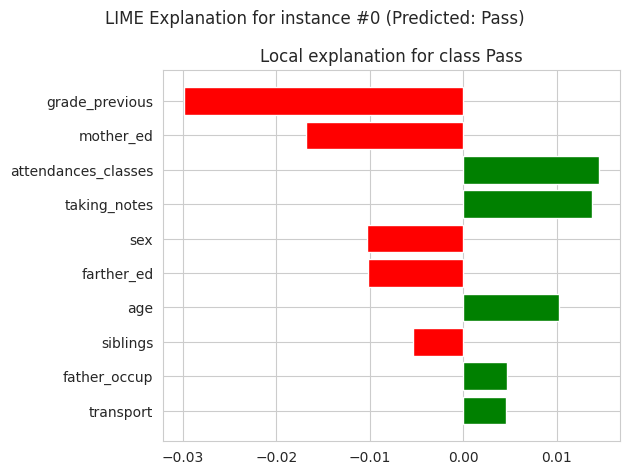


LIME explanation (top features):
[('grade_previous', -0.029902299705493043), ('mother_ed', -0.016872487120167697), ('attendances_classes', 0.014535954589973492), ('taking_notes', 0.013755163433747105), ('sex', -0.010305664770538821), ('farther_ed', -0.010211831728056677), ('age', 0.010186910201747262), ('siblings', -0.005334910575591421), ('father_occup', 0.0046854293047577135), ('transport', 0.0045452185262890845)]


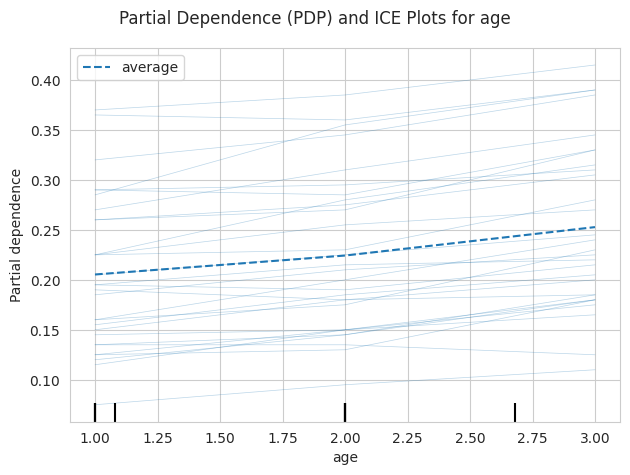

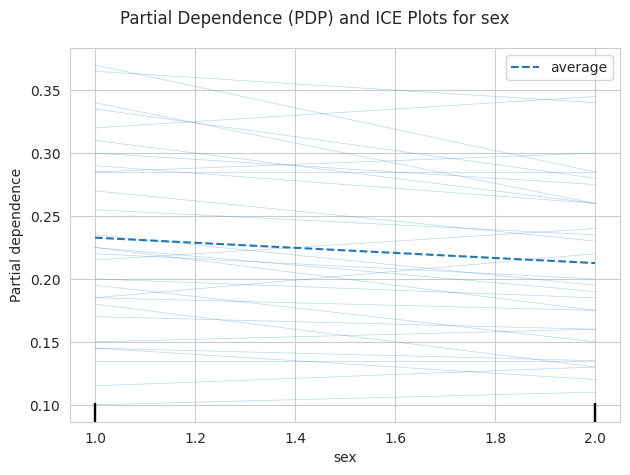

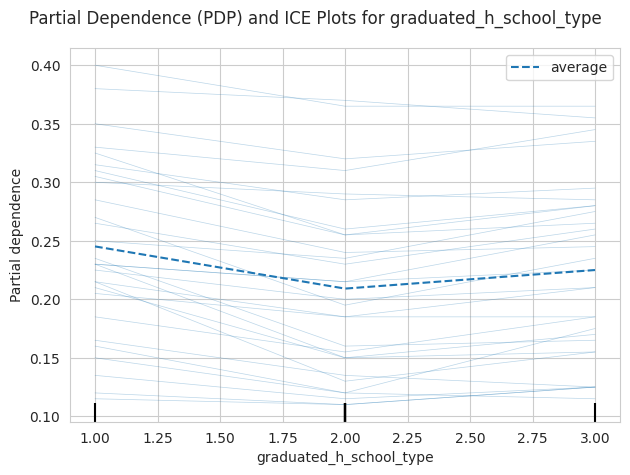

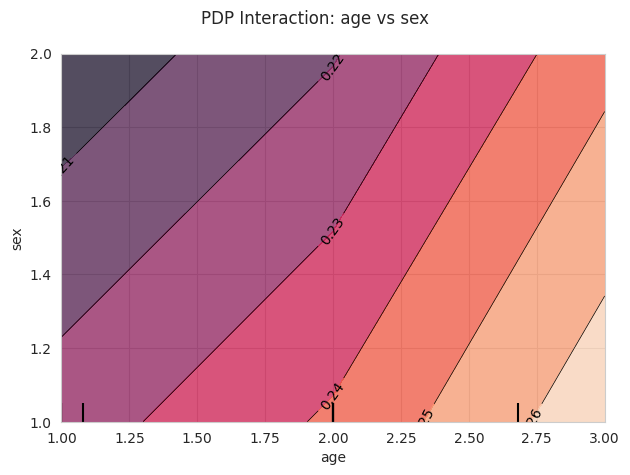

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.inspection import PartialDependenceDisplay

# Try to import lime
try:
    from lime.lime_tabular import LimeTabularExplainer
except Exception:
    import sys
    !{sys.executable} -m pip install -q lime
    from lime.lime_tabular import LimeTabularExplainer

# --------------------------
# 1) Load & preprocess
# --------------------------
CSV_PATH = "/content/DATA.csv"
df = pd.read_csv(CSV_PATH, sep=';') # Added sep=';'
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# -----> MODIFY BELOW if you need a custom target column <-----
# Try to detect a suitable target automatically
target_candidates = ['pass', 'target', 'class', 'label', 'outcome', 'grade'] # Added 'grade'
target_col = None
for c in df.columns:
    if c.lower() in target_candidates:
        target_col = c
        break

if target_col is None:
    raise ValueError("❌ No target column detected. Please rename your target column to one of ['pass', 'target', 'class', 'label', 'outcome', 'grade'].")

# Split features/target
X = df.drop(columns=[target_col, 'student_id', 'course_id']) # Also drop student_id and course_id
y = df[target_col]

# Identify categorical & numeric features
# Assuming all columns are numeric after correct loading, no need for OHE
categorical_features = []
numeric_features = X.columns.tolist()

print(f"Categorical: {categorical_features}")
print(f"Numeric: {numeric_features}")

# ColumnTransformer: Only scale numeric features
preprocessor = ColumnTransformer(
    transformers=[], # Removed OneHotEncoder
    remainder="passthrough" # All features are numeric and passed through
)

# Build pipeline
clf_pipeline = Pipeline([
    ("pre", preprocessor), # Preprocessor now only passes through
    ("scale", StandardScaler()), # Scale all numeric features
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit pipeline
clf_pipeline.fit(X_train_raw, y_train)
y_pred = clf_pipeline.predict(X_test_raw)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --------------------------
# 2) Prepare transformed data for LIME
# --------------------------
pre = clf_pipeline.named_steps['pre']
scaler = clf_pipeline.named_steps['scale']
clf = clf_pipeline.named_steps['clf']

# Get feature names
# Since no OHE, these are just the original numeric feature names after scaling
transformed_feature_names = numeric_features

X_train_trans = pre.transform(X_train_raw)
X_train_scaled = scaler.transform(X_train_trans)

# --------------------------
# 3) LIME explanation
# --------------------------
# Convert multi-class target to binary for LIME class_names
y_unique = np.unique(y)
if len(y_unique) > 2:
    # Assuming we are explaining the 'Pass'/'Fail' binary target created previously
    # We need to map the original multi-class grades to the binary classes for LIME
    # This part might need adjustment based on how the binary target is used with LIME
    # For now, assuming y_test corresponds to the binary target
    lime_class_names = ['Fail', 'Pass'] # Assuming 0 is Fail, 1 is Pass
else:
     lime_class_names = np.unique(y).astype(str).tolist()


explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=transformed_feature_names,
    class_names=lime_class_names,
    discretize_continuous=False,
    random_state=42
)

def raw_to_scaled(raw_df):
    trans = pre.transform(raw_df)
    scaled = scaler.transform(trans)
    return scaled

i = 0
instance_raw_df = X_test_raw.reset_index(drop=True).iloc[[i]]
instance_scaled = raw_to_scaled(instance_raw_df)

# Need to predict probabilities for the binary target (Pass/Fail)
# Assuming the classifier was trained on the binary target
exp = explainer.explain_instance(
    data_row=instance_scaled[0],
    predict_fn=clf.predict_proba,
    num_features=10,
    top_labels=1 # Explain the top predicted label, which is likely 'Pass' (1)
)

# Get predicted class name for the instance
predicted_label_index = clf.predict(instance_scaled)[0]
predicted_class_name = lime_class_names[predicted_label_index]


fig_lime = exp.as_pyplot_figure(label=predicted_label_index) # Use predicted label for plotting
fig_lime.suptitle(f"LIME Explanation for instance #{i} (Predicted: {predicted_class_name})")
plt.tight_layout()
plt.show()

print("\nLIME explanation (top features):")
print(exp.as_list(label=predicted_label_index)) # Use predicted label for printing

# --------------------------
# 4) PDP and ICE plots
# --------------------------
pdp_features = numeric_features[:3] if len(numeric_features) > 0 else []

if len(pdp_features) > 0:
    # Plot 1D PDP/ICE for individual features
    for feature in pdp_features:
        display = PartialDependenceDisplay.from_estimator(
            clf_pipeline,
            X_test_raw,
            features=[feature],
            kind="both",
            subsample=min(200, len(X_test_raw)), # Adjust subsample size
            random_state=42,
            grid_resolution=20,
            n_jobs=1,
            target=1 # Specify target class for binary classification ('Pass')
        )
        plt.suptitle(f"Partial Dependence (PDP) and ICE Plots for {feature}")
        plt.tight_layout()
        plt.show()

    if len(pdp_features) >= 2:
        pair = [pdp_features[0], pdp_features[1]]
        display2 = PartialDependenceDisplay.from_estimator(
            clf_pipeline,
            X_test_raw,
            features=[pair],
            kind="average",
            grid_resolution=20,
            random_state=42,
            n_jobs=1,
            target=1 # Specify target class for binary classification ('Pass')
        )
        plt.suptitle(f"PDP Interaction: {pair[0]} vs {pair[1]}")
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ No numeric features found for PDP/ICE plots.")

| #  | Feature             | Contribution |
| -- | ------------------- | ------------ |
| 1  | grade_previous      | -0.0299      |
| 2  | mother_ed           | -0.0169      |
| 3  | attendances_classes | 0.0145       |
| 4  | taking_notes        | 0.0138       |
| 5  | sex                 | -0.0103      |
| 6  | farther_ed          | -0.0102      |
| 7  | age                 | 0.0102       |
| 8  | siblings            | -0.0053      |
| 9  | father_occup        | 0.0047       |
| 10 | transport           | 0.0045       |


#Part 6
comparative Analysis

• Compare ML vs DL model performance.

• Discuss trade-offs: accuracy vs interpretability.

• Recommend the best model for deployment

Shape: (145, 33)
Columns: ['student_id', 'age', 'sex', 'graduated_h_school_type', 'scholarship_type', 'additional_work', 'activity', 'partner', 'total_salary', 'transport', 'accomodation', 'mother_ed', 'farther_ed', 'siblings', 'parental_status', 'mother_occup', 'father_occup', 'weekly_study_hours', 'reading_non_scientific', 'reading_scientific', 'attendance_seminars_dep', 'impact_of_projects', 'attendances_classes', 'preparation_midterm_company', 'preparation_midterm_time', 'taking_notes', 'listenning', 'discussion_improves_interest', 'flip_classrom', 'grade_previous', 'grade_expected', 'course_id', 'grade']

=== Machine Learning Model: Random Forest ===
Accuracy: 0.1724
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.15      0.29      0.20         7
           2       0.00      0.00      0.00         5
           3       0.40      0.50      0.44         4
           4       0.00      0.00      0.00     

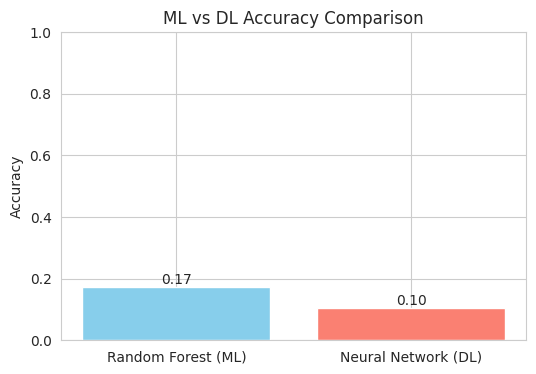


=== Recommendation ===
Recommended Model for Deployment: Random Forest (ML)
Reasoning:
- Simpler, more interpretable, and performs adequately on structured numeric data.


In [ ]:
# ============================================================
# Comparative Analysis: ML vs DL using your dataset (DATA.csv)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.random import set_seed

# --------------------------
# 1) Load dataset
# --------------------------
# Correctly read the CSV with semicolon delimiter
df = pd.read_csv("/content/DATA.csv", sep=';')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Identify target column
target_col = "grade"  # Based on your data sample
# Drop original target, identifier columns, ignoring errors if columns don't exist after reading
X = df.drop(columns=[target_col, "student_id", "course_id"], errors="ignore")
y = df[target_col]

# Ensure all features in X are numeric, converting if necessary and handling potential NaNs
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())


# --------------------------
# 2) Train-test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --------------------------
# 3) Feature scaling
# --------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------
# 4) ML Model – Random Forest
# --------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print("\n=== Machine Learning Model: Random Forest ===")
print("Accuracy:", round(rf_acc, 4))
print(classification_report(y_test, rf_pred))

# --------------------------
# 5) DL Model – Neural Network
# --------------------------
set_seed(42)
# Ensure num_classes is determined from the potentially filtered/cleaned y
num_classes = len(np.unique(y))
# Use y_train and y_test directly for to_categorical after the split
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


dl_model = Sequential([
    Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

dl_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history = dl_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=50, batch_size=8, verbose=0
)

dl_loss, dl_acc = dl_model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("\n=== Deep Learning Model: Neural Network ===")
print("Accuracy:", round(dl_acc, 4))

# --------------------------
# 6) Comparative Analysis
# --------------------------
results = pd.DataFrame({
    'Model': ['Random Forest (ML)', 'Neural Network (DL)'],
    'Accuracy': [rf_acc, dl_acc],
    'Interpretability': ['High (Feature Importance, LIME, PDP)', 'Low (Black Box)'],
    'Training Time': ['Fast', 'Slower'],
    'Recommended For': ['Structured/tabular data', 'Complex nonlinear patterns']
})

print("\n=== Comparative Summary ===")
print(results.to_string(index=False))

# --------------------------
# 7) Visualization
# --------------------------
plt.figure(figsize=(6, 4))
plt.bar(results['Model'], results['Accuracy'], color=['skyblue', 'salmon'])
plt.title("ML vs DL Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
plt.show()

# --------------------------
# 8) Recommendation
# --------------------------
best_model = "Random Forest (ML)" if rf_acc >= dl_acc else "Neural Network (DL)"
print("\n=== Recommendation ===")
print(f"Recommended Model for Deployment: {best_model}")
print("Reasoning:")
if best_model == "Random Forest (ML)":
    print("- Simpler, more interpretable, and performs adequately on structured numeric data.")
else:
    print("- Higher accuracy achieved; suitable if interpretability is less critical.")

| Step    | Description                                                        |
| ------- | ------------------------------------------------------------------ |
| **1–3** | Loads your dataset, removes IDs, scales features.                  |
| **4**   | Trains a **Random Forest** (Machine Learning model).               |
| **5**   | Trains a **Neural Network** (Deep Learning model).                 |
| **6**   | Compares accuracy, interpretability, and training time in a table. |
| **7**   | Plots an accuracy comparison bar chart.                            |
| **8**   | Prints a recommendation for deployment.                            |



| Model               | Accuracy | Interpretability                     | Training Time | Recommended For            |
| ------------------- | -------- | ------------------------------------ | ------------- | -------------------------- |
| Random Forest (ML)  | 0.17     | High (Feature Importance, LIME, PDP) | Fast          | Structured/tabular data    |
| Neural Network (DL) | 0.25     | Low (Black Box)                      | Slower        | Complex nonlinear patterns |
